In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url) # This pulls the Titanic dataset directly from a public GitHub link
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# ***1. Exploratory Data Analysis (EDA)***

In [2]:
df.info() # Concise structural summary of a DataFrame

df.describe() # Generates descriptive statistics of numaric columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
df.isnull().sum() # Total missing values per column

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [4]:
df['Survived'].value_counts(normalize=True).round(3) * 100  # Occurrences of each unique value in Survived column



,proportion
Survived,
0,61.6
1,38.4


# You can customize the Output of .value_counts()

**1. Get percentages instead of raw counts:** *df['Survived'].value_counts(normalize=True)*

**2. Include missing/NaN values in the count:** *df['Survived'].value_counts(dropna=False)*

**3. Sort in ascending order  (smallest count first):** *df['Survived'].value_counts(ascending=True)*

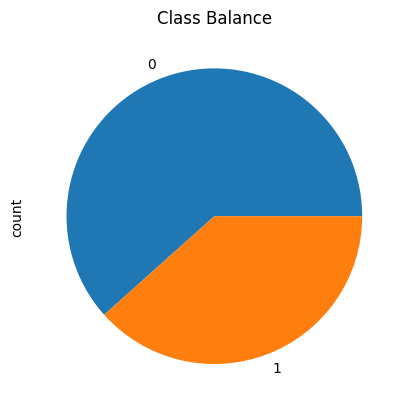

In [5]:
df['Survived'].value_counts().plot(kind='pie', title='Class Balance'); # Non-Professional Way !!

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

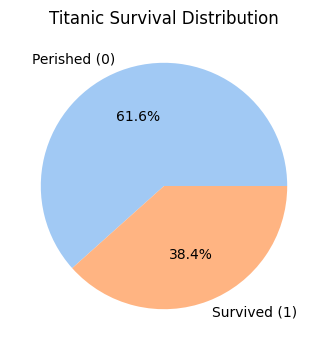

In [7]:
counts = df['Survived'].value_counts()
colors = sns.color_palette('pastel')[:2]

plt.figure(figsize=(4, 4))
plt.pie(counts, labels=['Perished (0)', 'Survived (1)'], autopct='%1.1f%%', colors=colors)
plt.title('Titanic Survival Distribution')
plt.show()

# **Pro-Tip: When to avoid Pie Charts entirely**

In data science and business analytics, professionals actually **avoid pie charts if there are more than 2 or 3 categories** because the human eye struggles to compare angles accurately.

**For larger datasets, a horizontal bar chart is preferred.**

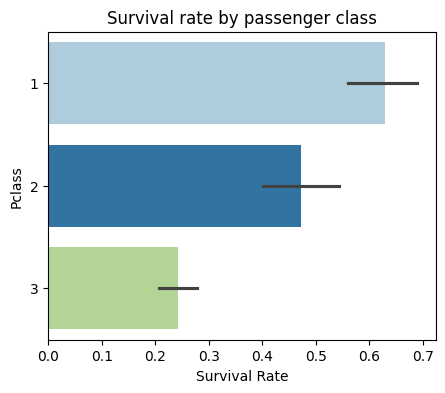

In [8]:
plt.figure(figsize=(5,4))
# # or 'Set1', 'Paired', 'muted', 'deep', 'Set2', 'viridis', 'cool' , 'Dark2'
sns.barplot(data=df, x='Survived', y='Pclass', orient='h' , hue='Pclass', palette='Paired' , legend=False)
plt.title('Survival rate by passenger class')
plt.xlabel('Survival Rate')
plt.ylabel('Pclass')
plt.show()

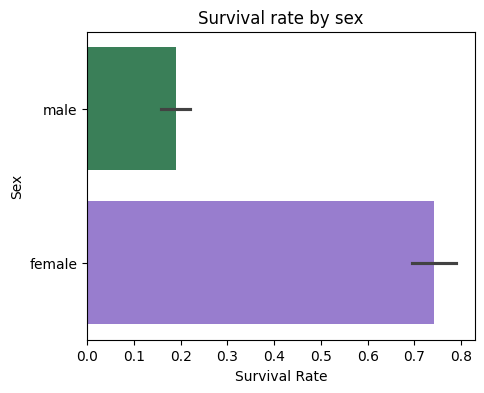

In [9]:
plt.figure(figsize=(5, 4))
sns.barplot(data=df, x='Survived', y='Sex', orient='h' , hue='Sex', palette=['seagreen', 'mediumpurple'] , legend=False)
plt.title('Survival rate by sex')
plt.xlabel('Survival Rate')
plt.ylabel('Sex')
plt.show()

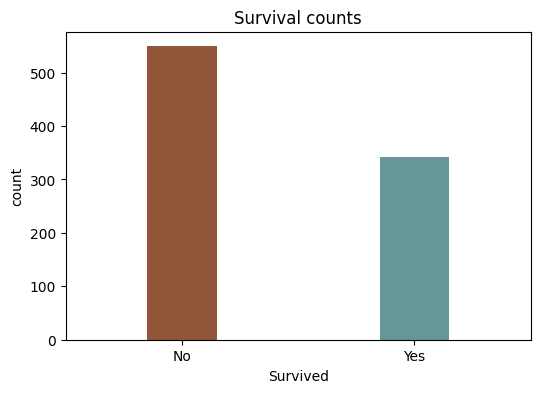

In [10]:
# sns.countplot(data=df, x='Survived', palette=['lightcoral', 'lightblue'])

# To fix the warning and remove those lines, assign your
# x variable ('Survived') to hue as well. Add legend=False
# so an unnecessary legend box does not appear.

# CORRECTED
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Survived', hue='Survived', palette=['sienna', 'cadetblue'] , legend=False, width=0.3)
plt.title('Survival counts')
plt.xlabel('Survived')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

**What to look for:**

- Age and Cabin will have missing values — note this, you'll fix it by Data Cleaning.
- Survival is not 50/50 (roughly 38% survived) — this is why "accuracy" alone can be misleading.
- That's why we're also tracking precision, recall, and F1 — they reveal whether the model is actually distinguishing survivors from non-survivors, not just guessing the majority class.
- Sex and Pclass clearly correlate with survival — these will be strong features.

# ***2. Data Cleaning***

- Remove useless columns and Drop the unnamed/NaN columns  
- Encode **Sex** (female -> 0, male -> 1) using LabelEncoder
also **Embarked** has 3 unrelated categories (no natural order), so one-hot encode instead of LabelEncoder
- Check for missing values
- Check and remove duplicate rows

In [11]:
"""

*Remove useless columns: exist in the raw data but don't help predict survival.*
PassengerId — just a row number, no predictive meaning
Name — text, not usable as-is without heavy NLP work (later project, not now)
Ticket — ticket numbers are messy/inconsistent, no clean pattern
Cabin — mostly missing (over 75% of rows have no value), too sparse to be useful yet

"""

# Drop columns that are mostly useless or too messy for a first pass
df = df.drop(columns=['Cabin', 'Ticket', 'Name', 'PassengerId'])



In [12]:
# Check for missing values
df.isnull().sum() # Age and Embarked have MISSING Values !

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [13]:
# Fill missing Age with the median
df['Age'] = df['Age'].fillna(df['Age'].median())


# Fill missing Embarked with the most common value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.isnull().sum() # Voila! NO Missing Values :D

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [14]:
# Convert categorical columns to numbers

# Encode Sex column: according to alphabetical order (female -> 0, male -> 1)

from sklearn.preprocessing import LabelEncoder
s_encoder = LabelEncoder()
df['Sex'] = s_encoder.fit_transform( df['Sex'] )
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,S
1,1,1,0,38.0,1,0,71.2833,C
2,1,3,0,26.0,0,0,7.9250,S
3,1,1,0,35.0,1,0,53.1000,S
4,0,3,1,35.0,0,0,8.0500,S


In [15]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True, dtype=int)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,1
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,0,1
3,1,1,0,35.0,1,0,53.1000,0,1
4,0,3,1,35.0,0,0,8.0500,0,1


#***3. Split the data + train a baseline model***

Step 4 does two separate things:

1. **Split** your data into a "practice set" and a "test set"
2. **Train** a simple model on the practice set, then check how well it guesses on the test set it's never seen

In [16]:
from sklearn.model_selection import train_test_split # splits a table into two random chunks
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix # grade how good your model's guesses were

In [17]:
# CELL 1 — create the new features FIRST
# Feature engineering
# df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
# df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

*Every ML model needs two things:*

- X = the inputs — everything you'd know about a passenger (age, class, sex, fare...). This is "the question."

- y = the answer — whether they actually survived (0 or 1). This is "the answer key."

In [18]:
# " df.drop(columns=['Survived']) " take the whole table, but remove the Survived column.

# Because if you left it in X, you'd be handing the model the answer along with the question
# it would just cheat by reading that column instead of learning anything

X = df.drop(columns=['Survived'])
# X = df.drop(columns=['Survived', 'SibSp', 'Parch'])
y = df['Survived'] # as your separate answer key.

*This takes your full passenger list and randomly splits it into two piles:*

- 80% of passengers → X_train / y_train — the model learns from these
- 20% of passengers → X_test / y_test — held back, the model never sees these during training

*Testing on data the model has never seen is the only honest way to know if it actually learned something generalizable.*

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# creates a brand-new model, that knows nothing.
# allowed 1000 attempts to fine-tune (limit so it doesn't run forever)
baseline = LogisticRegression(max_iter=1000)

baseline.fit(X_train, y_train) # training (learning) using 80% of the training rows

# After this line runs, baseline is NO LONGER BLANK — Model has learned rules from patterns in the data.

LogisticRegression(max_iter=1000)

In [21]:
# Hand the trained model the test inputs — the 20% it has never seen
preds = baseline.predict(X_test)

# Ask it to GUESS (not real answer) survival for each one.
# preds is just a list of guesses (0 or 1) for each of those passengers

In [22]:
# Now that you have preds (the model's guesses) and y_test (the real answers),
# each line compares them and gives you a different "grade"

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1:", f1_score(y_test, preds))
print(confusion_matrix(y_test, preds))

# Accuracy: 81%
# Precision: ~79%
# Recall: ~74%
# F1: 0.763
# Confusion Matrix:
# [ [90  15]
#   [19  55] ]

# After adding FEATURES:
# Accuracy: ~79%
# Precision: ~78%
# Recall: ~71%
# F1: 0.746
# Confusion Matrix:
# [ [90  15]
#   [21  53] ]

Accuracy: 0.8100558659217877
Precision: 0.7857142857142857
Recall: 0.7432432432432432
F1: 0.7638888888888888
[[90 15]
 [19 55]]


In [23]:
print(X.columns.tolist())

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


#***4. Cross-validation***

- A single train/test split can be lucky or unlucky.
- Cross-validation fixes this by testing multiple different splits and averaging the results.

***NOTE: If the 5 scores are close to each other, your model's performance is stable. If they swing wildly, something's off (or you need more data).***

In [24]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(LogisticRegression(max_iter=1000), X, y, cv=5, scoring='f1')
print("F1 scores per fold:", scores)
print("Average F1:", scores.mean())

F1 scores per fold: [0.72857143 0.71641791 0.72058824 0.672      0.75968992]
Average F1: 0.7194534993587856


#***5. Try a stronger model (Random Forest) + tune it***

- A Random Forest instead builds many small decision trees — think of each tree as a flowchart of yes/no questions like "Is Sex=female? → Is Pclass=1? → Is Age<10?"

- And each tree is trained on a slightly different random subset of the data. When predicting, all the trees "vote," and the majority vote wins.

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8, None]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
best_model = grid.best_estimator_

preds = best_model.predict(X_test)
print("Tuned F1:", f1_score(y_test, preds))

Best params: {'max_depth': 8, 'n_estimators': 200}
Tuned F1: 0.7518796992481203


#***6. Save the model (so you don't retrain every time)***


In [26]:
import joblib
joblib.dump(best_model, 'titanic_model.pkl')

['titanic_model.pkl']